# Chapter 11 — Feature Engineering & Selection

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch11_features.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch11_features.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch11_features.ipynb)

> **Motivating question.** A classifier can't read a waveform — what numbers summarise a 30-s epoch well enough to name its sleep stage?

## What this notebook demonstrates

- Time and frequency features from an epoch (RMS, Hjorth, band power)
- Spectral entropy; the feature-scaling leakage trap
- Ranking features by mutual information; a 2-D LDA projection
- ECG fiducial-point features; early vs late multi-channel fusion

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | reduced (a lighter path runs in the browser) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from scipy import signal as sig
from scipy.stats import entropy as scipy_entropy
from sklearn.feature_selection import mutual_info_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

CH = 11

FS = 100.0
BANDS = {"delta": (0.5, 4), "theta": (4, 8), "alpha": (8, 11),
         "sigma": (11, 16), "beta": (16, 30)}
STAGES = ["W", "N2", "N3", "REM"]


def hjorth(x):
    dx = np.diff(x)
    ddx = np.diff(dx)
    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12
    activity = var0
    mobility = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)
    return activity, mobility, complexity


def spectral_entropy(x, fs):
    f, p = sig.welch(x, fs=fs, nperseg=min(len(x), 256))
    p = p / (p.sum() + 1e-12)
    return scipy_entropy(p) / np.log(len(p))


def extract(x, fs):
    feats = {}
    feats["rms"] = np.sqrt(np.mean(x ** 2))
    feats["zcr"] = np.mean(np.abs(np.diff(np.sign(x)))) / 2
    feats["var"] = np.var(x)
    a, m, c = hjorth(x)
    feats["hj_mob"] = m
    feats["hj_cmp"] = c
    total = bio.bandpower(x, fs, (0.5, 30)) + 1e-12
    for name, band in BANDS.items():
        feats[f"bp_{name}"] = bio.bandpower(x, fs, band)
        feats[f"rel_{name}"] = bio.bandpower(x, fs, band) / total
    feats["spec_ent"] = spectral_entropy(x, fs)
    return feats


def make_dataset(n_per=40, seed=100):
    rng = np.random.default_rng(seed)
    X, y, names = [], [], None
    for k, stage in enumerate(STAGES):
        for i in range(n_per):
            _, x = bio.eeg(duration=10.0, fs=FS, seed=int(rng.integers(1e6)),
                           stage=stage)
            f = extract(x, FS)
            if names is None:
                names = list(f.keys())
            X.append([f[nm] for nm in names])
            y.append(k)
    return np.array(X), np.array(y), names

## 11.1  feature concept

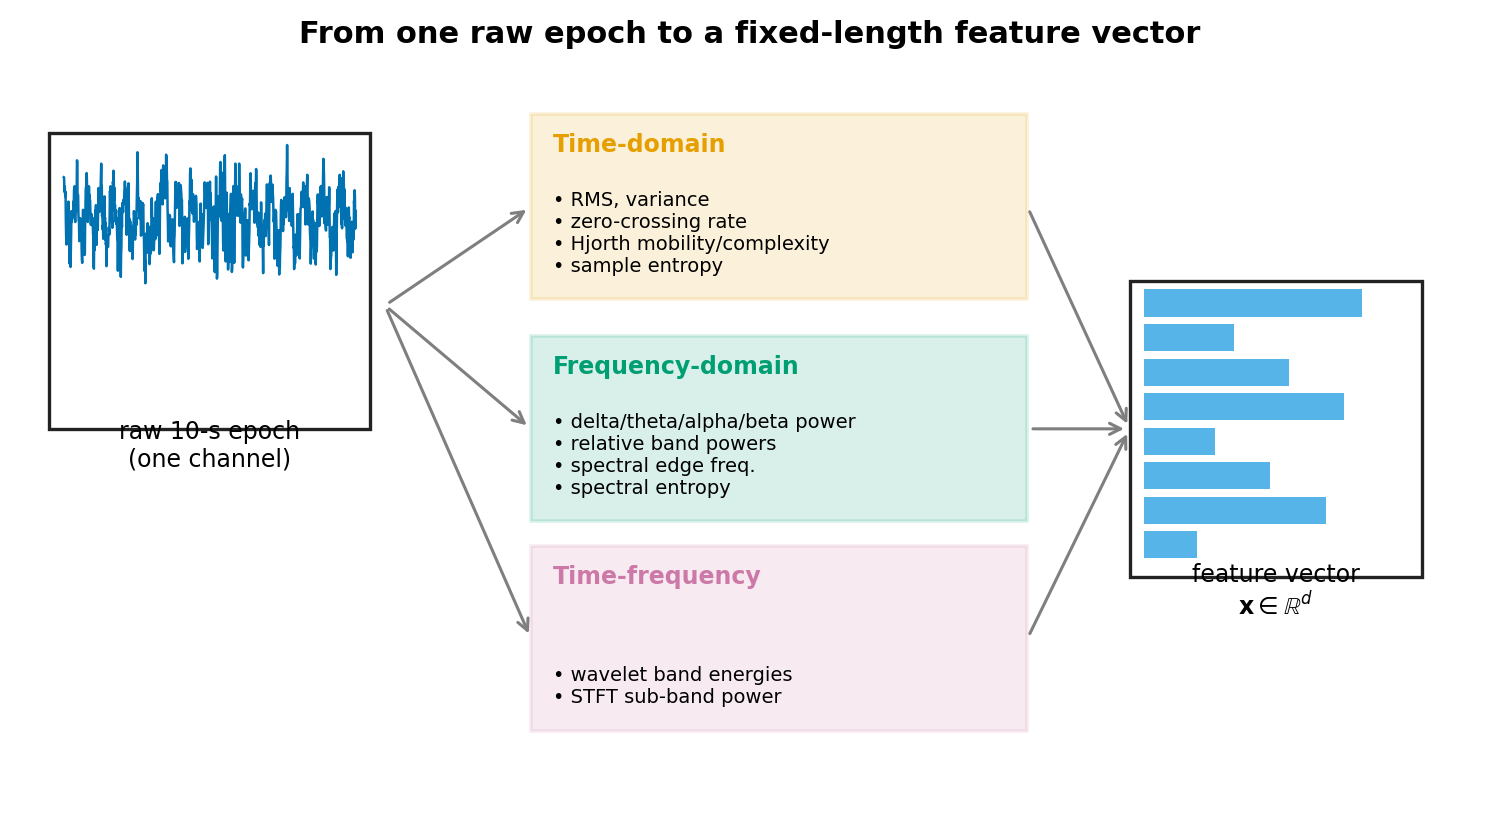

In [3]:
fig, ax = bs.newfig(w=7.6, h=4.2)
ax.axis("off")
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)

# raw epoch (draw a mini waveform)
_, x = bio.eeg(duration=10.0, fs=FS, stage="N2")
tt = np.linspace(0.3, 2.3, len(x))
xn = 0.7 + 0.8 * (x - x.min()) / (np.ptp(x) + 1e-9)
ax.plot(tt, xn * 1.4 + 3.2, color=bs.C["blue"], lw=0.9)
ax.add_patch(bs.plt.Rectangle((0.2, 3.0), 2.2, 2.4, fill=False,
             ec=bs.C["black"], lw=1.2))
ax.text(1.3, 2.7, "raw 10-s epoch\n(one channel)", ha="center", fontsize=8.5)

groups = [
    ("Time-domain", ["RMS, variance", "zero-crossing rate",
                      "Hjorth mobility/complexity", "sample entropy"],
     bs.C["orange"], 4.4),
    ("Frequency-domain", ["delta/theta/alpha/beta power",
                          "relative band powers", "spectral edge freq.",
                          "spectral entropy"], bs.C["green"], 2.6),
    ("Time-frequency", ["wavelet band energies",
                        "STFT sub-band power"], bs.C["purple"], 0.9),
]
for (title, items, col, ypos) in groups:
    ax.add_patch(bs.plt.Rectangle((3.5, ypos - 0.35), 3.4, 1.5,
                 fill=True, fc=col, alpha=0.15, ec=col, lw=1.3))
    ax.text(3.65, ypos + 0.85, title, fontsize=8.5, fontweight="bold",
            color=col)
    ax.text(3.65, ypos - 0.15, "\n".join(f"• {s}" for s in items),
            fontsize=7, va="bottom")
    ax.annotate("", xy=(3.5, ypos + 0.4), xytext=(2.5, 4.0),
                arrowprops=dict(arrowstyle="->", color=bs.C["grey"], lw=1.1))

# feature vector on the right
ax.add_patch(bs.plt.Rectangle((7.6, 1.8), 2.0, 2.4, fill=False,
             ec=bs.C["black"], lw=1.2))
for i in range(8):
    val = 0.2 + 0.7 * ((i * 37) % 10) / 10
    ax.add_patch(bs.plt.Rectangle((7.7, 1.95 + i * 0.28), 1.8 * val, 0.22,
                 fc=bs.C["sky"], ec="none"))
ax.text(8.6, 1.5, "feature vector\n$\\mathbf{x}\\in\\mathbb{R}^d$",
        ha="center", fontsize=8.5)
for ypos in (4.4, 2.6, 0.9):
    ax.annotate("", xy=(7.6, 3.0), xytext=(6.9, ypos + 0.4),
                arrowprops=dict(arrowstyle="->", color=bs.C["grey"], lw=1.1))
ax.set_title("From one raw epoch to a fixed-length feature vector")
plt.tight_layout()
plt.show()

## 11.2  feature heatmap

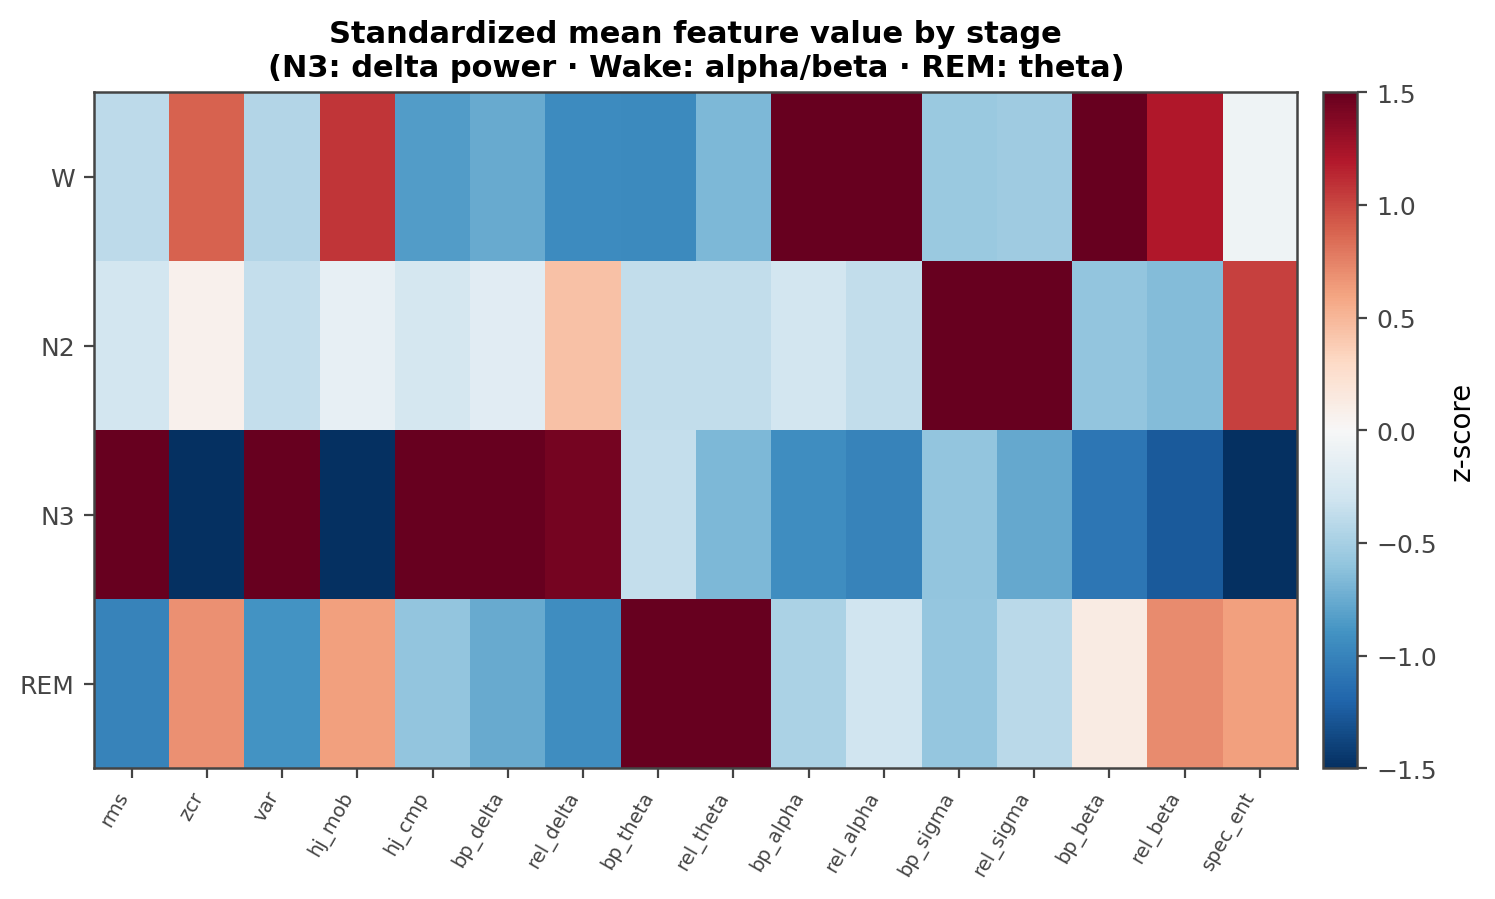

In [4]:
X, y, names = make_dataset(n_per=40)
# z-score each feature so the heatmap is comparable
Xz = StandardScaler().fit_transform(X)
mat = np.array([Xz[y == k].mean(axis=0) for k in range(len(STAGES))])  # stages x feats

fig, ax = bs.newfig(w=7.6, h=4.6)
im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", vmin=-1.5, vmax=1.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=60, ha="right", fontsize=7)
ax.set_yticks(range(len(STAGES)))
ax.set_yticklabels(STAGES)
ax.set_title("Standardized mean feature value by stage\n"
             "(N3: delta power · Wake: alpha/beta · REM: theta)")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="z-score")
plt.tight_layout()
plt.show()

## 11.3  selection

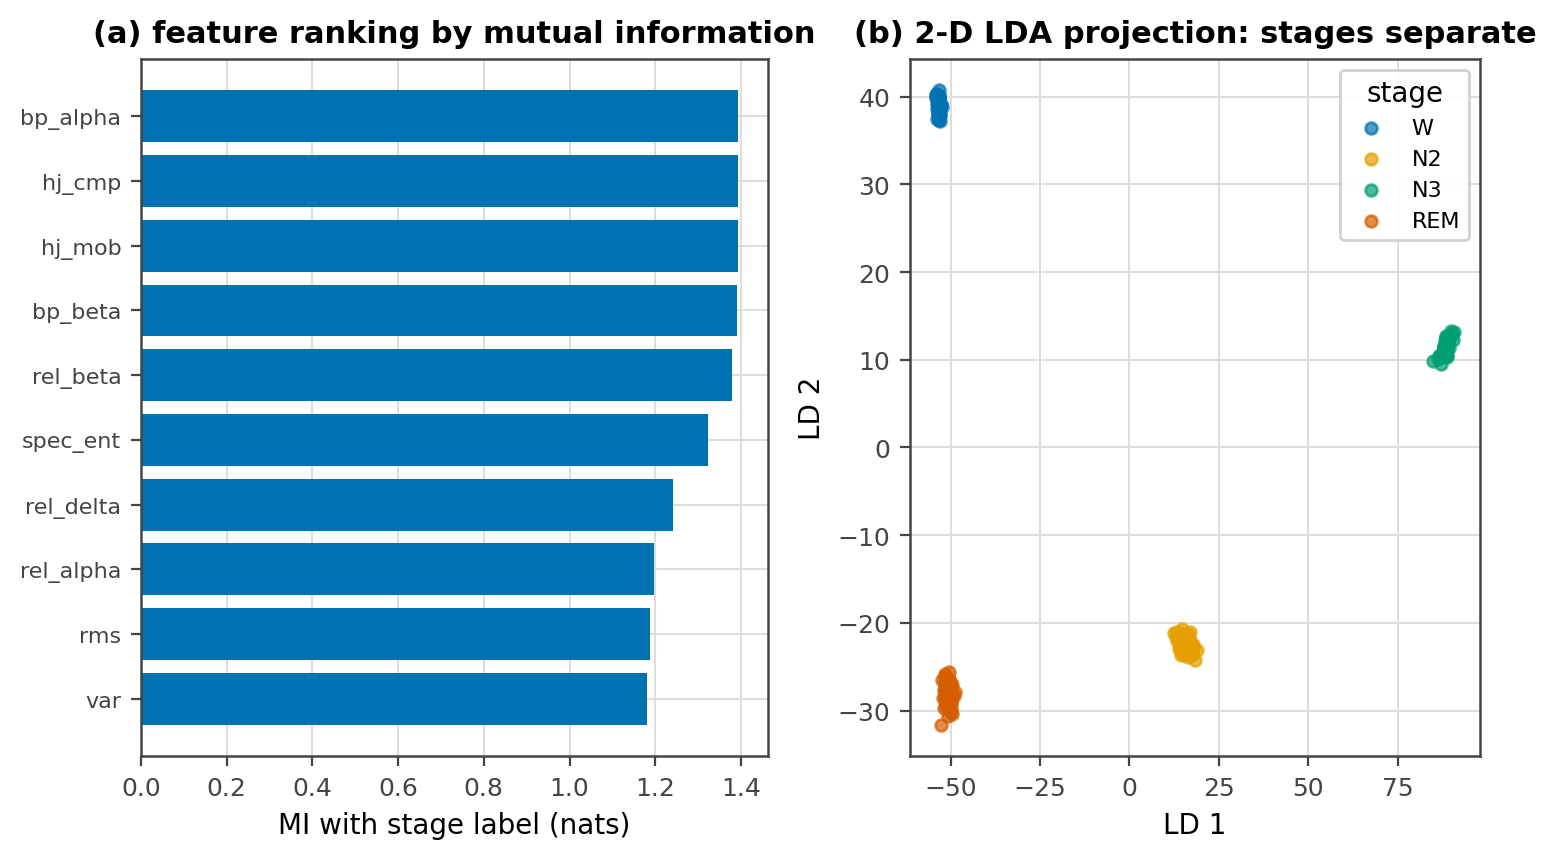

In [5]:
X, y, names = make_dataset(n_per=50)
mi = mutual_info_classif(X, y, random_state=0)
order = np.argsort(mi)[::-1]

fig, ax = bs.newfig(w=7.6, h=4.4, nrows=1, ncols=2,
                    gridspec_kw={"width_ratios": [1.1, 1.0]})

top = order[:10][::-1]
ax[0].barh([names[i] for i in top], mi[top], color=bs.C["blue"])
ax[0].set_title("(a) feature ranking by mutual information")
ax[0].set_xlabel("MI with stage label (nats)")
ax[0].tick_params(axis="y", labelsize=8)

# LDA to 2-D
Xz = StandardScaler().fit_transform(X)
lda = LinearDiscriminantAnalysis(n_components=2)
Z = lda.fit_transform(Xz, y)
cols = [bs.C["blue"], bs.C["orange"], bs.C["green"], bs.C["red"]]
for k, stage in enumerate(STAGES):
    ax[1].scatter(Z[y == k, 0], Z[y == k, 1], s=18, alpha=0.7,
                  color=cols[k], label=stage)
ax[1].set_title("(b) 2-D LDA projection: stages separate")
ax[1].set_xlabel("LD 1")
ax[1].set_ylabel("LD 2")
ax[1].legend(loc="best", fontsize=8, title="stage")
plt.tight_layout()
plt.show()

## 11.4  ecg fiducial

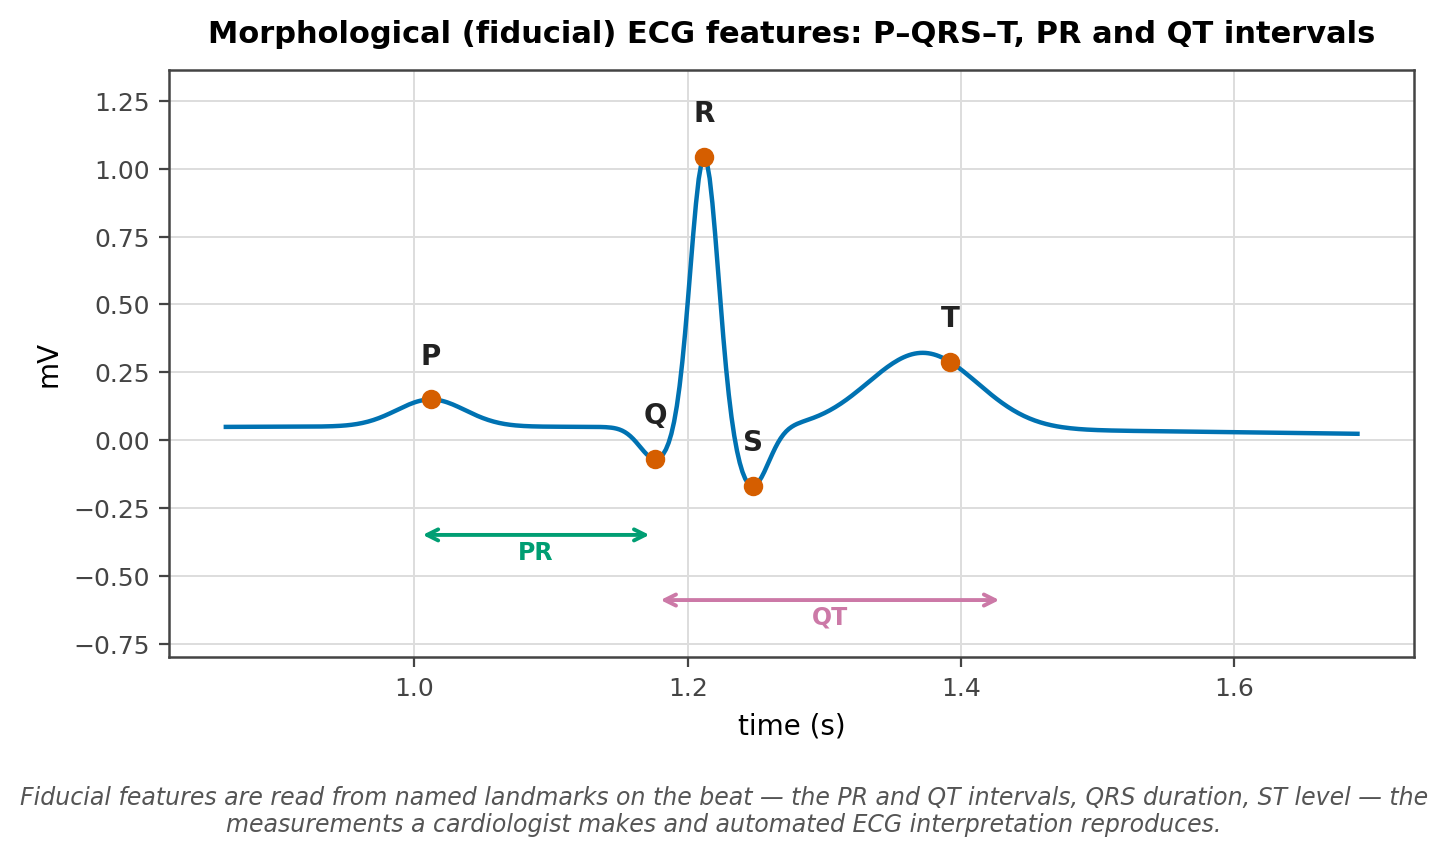

In [6]:
# Morphological / fiducial ECG features: the P, QRS, T landmarks and the PR / QT
# intervals a cardiologist reads. Landmarks located by local search around the R peak.
from scipy.signal import find_peaks
t, x = bio.ecg(duration=2.2, fs=500, hr=70, noise=0.0)
fs = 500.0
pk, _ = find_peaks(x, height=0.5 * np.max(x), distance=int(0.4 * fs))
ir = pk[len(pk) // 2]; tr = t[ir]

def loc(a, b, kind):
    i0, i1 = int(a * fs), int(b * fs)
    seg = x[i0:i1]
    j = int(np.argmax(seg) if kind == "max" else np.argmin(seg))
    return (i0 + j) / fs
P = loc(tr - 0.24, tr - 0.10, "max"); Q = loc(tr - 0.06, tr - 0.004, "min")
S = loc(tr + 0.004, tr + 0.06, "min"); T = loc(tr + 0.18, tr + 0.42, "max")
marks = [("P", P), ("Q", Q), ("R", tr), ("S", S), ("T", T)]

w0, w1 = ir - int(0.35 * fs), ir + int(0.48 * fs)
fig, ax = bs.newfig(w=7.2, h=3.9)
ax.plot(t[w0:w1], x[w0:w1], color=bs.C["blue"], lw=1.6)
for nm, tm in marks:
    im = int(tm * fs)
    ax.plot(tm, x[im], "o", color=bs.C["red"], ms=6)
    ax.annotate(nm, (tm, x[im]), (tm, x[im] + 0.13), ha="center", fontsize=10,
                fontweight="bold", color=bs.C["black"])
ybase = float(np.min(x[w0:w1])) - 0.18

def bracket(x0, x1, y, label, col):
    ax.annotate("", xy=(x1, y), xytext=(x0, y), arrowprops=dict(arrowstyle="<->", color=col, lw=1.4))
    ax.text((x0 + x1) / 2, y - 0.09, label, ha="center", fontsize=8.5, color=col, fontweight="bold")
bracket(P - 0.01, Q, ybase, "PR", bs.C["green"])
bracket(Q, T + 0.04, ybase - 0.24, "QT", bs.C["purple"])
ax.set_xlabel("time (s)"); ax.set_ylabel("mV")
ax.set_ylim(ybase - 0.45, float(np.max(x[w0:w1])) + 0.32)
ax.set_title("Morphological (fiducial) ECG features: P–QRS–T, PR and QT intervals", pad=10)
bs.takeaway(fig, "Fiducial features are read from named landmarks on the beat — the PR and QT intervals, "
                 "QRS duration, ST level — the measurements a cardiologist makes and automated ECG interpretation reproduces.")
plt.tight_layout()
plt.show()

## 11.5  feature fusion

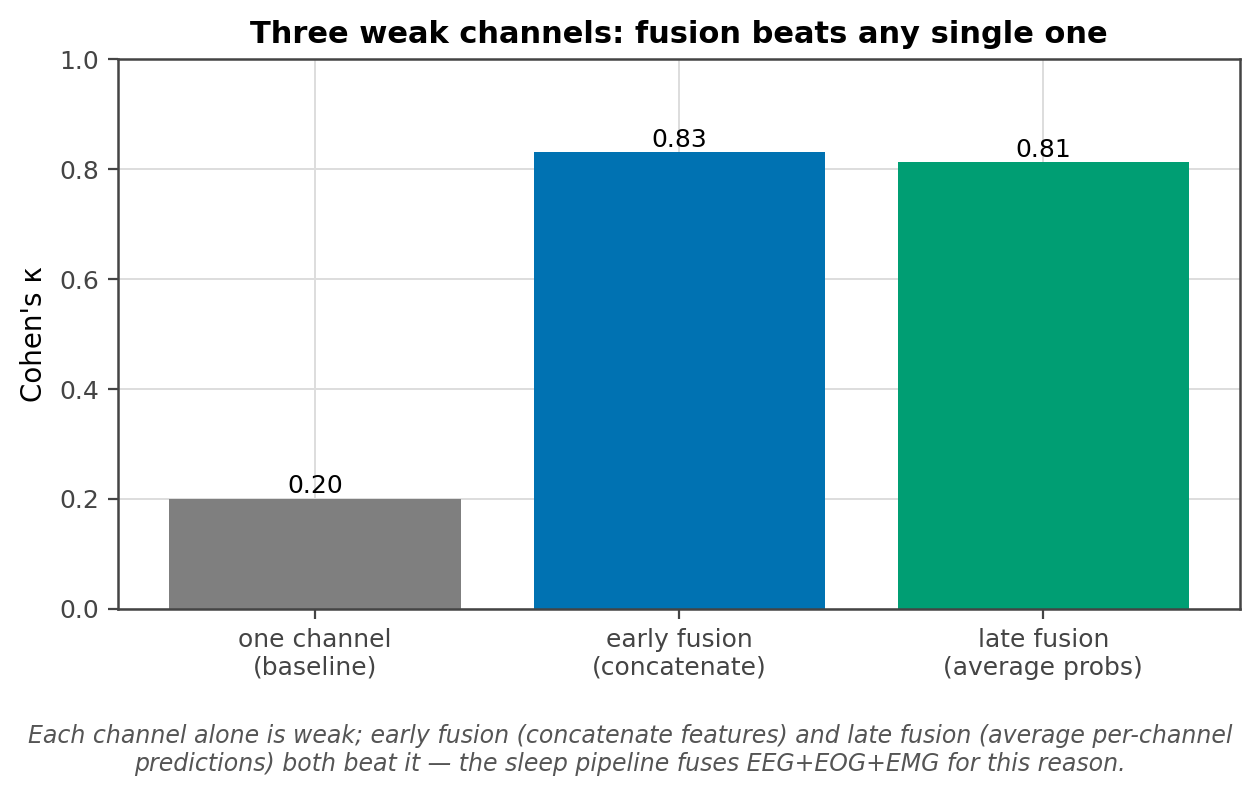

In [7]:
# Combining several weak "channels": early fusion (concatenate features) vs
# late fusion (average per-channel predictions) vs a single channel.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
r = np.random.default_rng(11)
n, C = 600, 3
y = r.integers(0, C, n)

def channel(strength, seed):
    rr = np.random.default_rng(seed)
    means = rr.standard_normal((C, 3)) * strength
    return means[y] + rr.standard_normal((n, 3))
chans = [channel(0.8, 1), channel(0.8, 2), channel(0.8, 3)]
tr, te = train_test_split(np.arange(n), test_size=0.4, random_state=0, stratify=y)
ytr, yte = y[tr], y[te]

rf1 = RandomForestClassifier(200, random_state=0).fit(chans[0][tr], ytr)
k_one = cohen_kappa_score(yte, rf1.predict(chans[0][te]))
Xe = np.hstack(chans)
rfe = RandomForestClassifier(200, random_state=0).fit(Xe[tr], ytr)
k_early = cohen_kappa_score(yte, rfe.predict(Xe[te]))
probs = np.zeros((len(te), C))
for cx in chans:
    m = RandomForestClassifier(200, random_state=0).fit(cx[tr], ytr)
    probs += m.predict_proba(cx[te])
k_late = cohen_kappa_score(yte, probs.argmax(1))

fig, ax = bs.newfig(w=6.4, h=3.6)
names = ["one channel\n(baseline)", "early fusion\n(concatenate)", "late fusion\n(average probs)"]
ks = [k_one, k_early, k_late]
bars = ax.bar(names, ks, color=[bs.C["grey"], bs.C["blue"], bs.C["green"]])
for b, k in zip(bars, ks):
    ax.text(b.get_x() + b.get_width() / 2, k + 0.01, f"{k:.2f}", ha="center", fontsize=9)
ax.set_ylabel("Cohen's κ"); ax.set_ylim(0, 1)
ax.set_title("Three weak channels: fusion beats any single one")
bs.takeaway(fig, "Each channel alone is weak; early fusion (concatenate features) and late fusion "
                 "(average per-channel predictions) both beat it — the sleep pipeline fuses EEG+EOG+EMG for this reason.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above exactly. Change a parameter and watch them move — that loop between the page and the running code is where the intuition forms.

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `bandpower`, `entropy`; scale with `zscore` (train only).

## Leakage-safety checklist

Any ML step in this notebook must obey:

- no scaling or feature selection **before** the split;
- no epoch-level random split when claiming new-subject generalisation (use LOSO / GroupKFold);
- every reported metric states its split unit (epoch, subject, night);
- synthetic performance is labelled *illustrative*, never clinical.

In [8]:
from bsp.notebook_checks import assert_no_subject_leak
# Example guard used throughout the pipeline notebooks:
# assert_no_subject_leak(groups[train_idx], groups[test_idx])

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Build the epoch → feature matrix and rank features by mutual information.

<details><summary>💡 Hint &amp; what you should see</summary>

Band-power and spindle/EOG features should top the MI ranking for sleep; MI captures **non-linear** relevance a correlation misses. Expect a few features to dominate.

</details>

**2.** Show why the scaler must be fit on the training fold only.

<details><summary>💡 Hint &amp; what you should see</summary>

Fitting the scaler on all data leaks test statistics (mean/std) into training → optimistic scores. Refit inside each fold (a `Pipeline`) and the honest score **drops slightly** — that drop is the leak you removed.

</details>

In [9]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch11_figures.py`.*